# Day 2 — ALT Trend: Rolling Mean + Clinical Thresholds
**Goal:** Smooth lab values (ALT) using a rolling mean and interpret against ULN thresholds.

**Dataset:** `../data/day2/alt_trend_day2.csv` (120 days simulated). ULN = 40 U/L.

**Flow:**
1. Load data
2. Compute rolling mean (window=7)
3. Visualize raw vs smoothed ALT and ULN lines
4. Detect sustained elevations
5. Practice tasks (TODO cells)


In [ ]:
# Step 1 — Load data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/alt_trend_day2.csv')
df.head()

,day,ALT
0,1,28.4
1,2,24.1
2,3,25.1
3,4,25.8
4,5,23.4


In [ ]:
# Step 2 — Compute rolling mean (demo)
# A 7-day window uses the current day + previous 6 days.
df['ALT_roll7'] = df['ALT'].rolling(window=7, min_periods=1).mean()
df[['day','ALT','ALT_roll7']].head(10)

,day,ALT,ALT_roll7
0,1,28.4,28.400000
1,2,24.1,26.250000
2,3,25.1,25.866667
3,4,25.8,25.850000
4,5,23.4,25.360000
5,6,25.0,25.300000
6,7,25.0,25.257143
7,8,21.5,24.271429
8,9,27.0,24.685714
9,10,26.2,24.842857


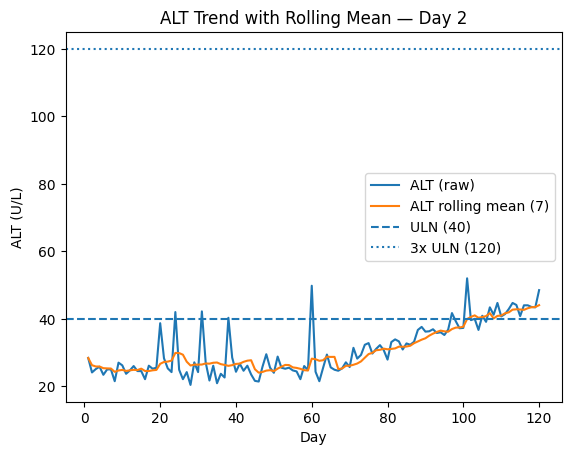

In [ ]:
# Step 3 — Plot raw vs rolling mean with ULN references (demo)
ULN = 40.0

plt.figure()
plt.plot(df['day'], df['ALT'], label='ALT (raw)')
plt.plot(df['day'], df['ALT_roll7'], label='ALT rolling mean (7)')
plt.axhline(ULN, linestyle='--', label='ULN (40)')
plt.axhline(3*ULN, linestyle=':', label='3x ULN (120)')
plt.xlabel('Day')
plt.ylabel('ALT (U/L)')
plt.title('ALT Trend with Rolling Mean — Day 2')
plt.legend()
plt.show()

Enable Claude Sonnet 3.5 for all clients
[object Object]

In [ ]:
# Step 4 — Detect sustained elevations (demo)
# Rule: mark days where ALT_roll7 >= ULN (40), then count consecutive days.
df['above_ULN'] = df['ALT_roll7'] >= 40.0

runs = []
run = 0
for v in df['above_ULN']:
    if v:
        run += 1
    else:
        run = 0
    runs.append(run)
df['run_len_ULN'] = runs

print(df[['day','ALT','ALT_roll7','above_ULN','run_len_ULN']])

     day   ALT  ALT_roll7  above_ULN  run_len_ULN
0      1  28.4  28.400000      False            0
1      2  24.1  26.250000      False            0
2      3  25.1  25.866667      False            0
3      4  25.8  25.850000      False            0
4      5  23.4  25.360000      False            0
5      6  25.0  25.300000      False            0
6      7  25.0  25.257143      False            0
7      8  21.5  24.271429      False            0
8      9  27.0  24.685714      False            0
9     10  26.2  24.842857      False            0
10    11  23.7  24.542857      False            0
11    12  24.7  24.728571      False            0
12    13  26.0  24.871429      False            0
13    14  24.5  24.800000      False            0
14    15  24.5  25.228571      False            0
15    16  22.1  24.528571      False            0
16    17  26.1  24.514286      False            0
17    18  25.2  24.728571      False            0
18    19  25.5  24.842857      False            0


## ✅ Practice — TODO 1: Try a different window size
- Create a new column `ALT_roll5` using a 5-day rolling mean.
- Plot it against the raw series and ULN lines.
- Compare how the curve smoothness changes vs window=7.


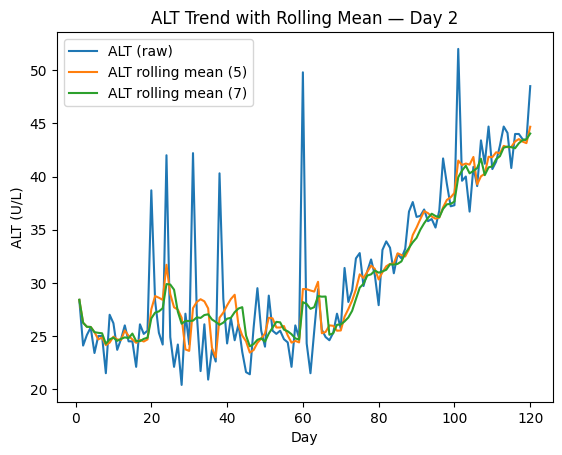

In [ ]:
# TODO 1 — code here

df['ALT_roll5'] = df['ALT'].rolling(window=5, min_periods=1).mean()
plt.figure()
plt.plot(df['day'], df['ALT'], label='ALT (raw)')
plt.plot(df['day'], df['ALT_roll5'], label='ALT rolling mean (5)')
plt.plot(df['day'], df['ALT_roll7'], label='ALT rolling mean (7)')
plt.xlabel('Day')
plt.ylabel('ALT (U/L)')
plt.title('ALT Trend with Rolling Mean — Day 2')
plt.legend()
plt.show()


## ✅ Practice — TODO 2: Robust outlier detection (MAD)
Implement a Median Absolute Deviation rule:
1) median_ALT = median(ALT)
2) MAD = median(|ALT - median_ALT|)
3) Flag outliers where |ALT - median_ALT| / MAD > 4.5
4) Plot those outliers on the raw series.


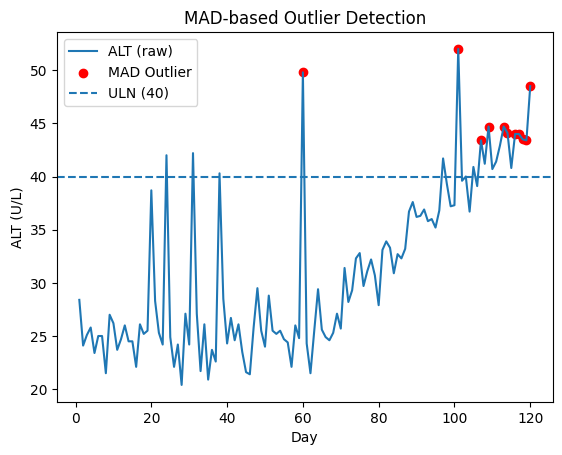

In [ ]:
# TODO 2 — code here

# Step 1 — median，MAD
median_ALT = df['ALT'].median()
mad_ALT = (df['ALT']-median_ALT).abs().median()

# Step 2 — z-score
df['MAD_z'] = df['ALT'].apply(lambda x: abs(x - median_ALT) / mad_ALT if mad_ALT != 0 else 0)

# Step 3 — outlier
df['mad_outlier'] = df['MAD_z'] > 3.5

# print(df[['day','ALT','MAD_z','mad_outlier']])
# Step 4 — plot
plt.figure()
plt.plot(df['day'], df['ALT'], label='ALT (raw)')
plt.scatter(df.loc[df['mad_outlier'], 'day'],
            df.loc[df['mad_outlier'], 'ALT'],
            color='red', label='MAD Outlier')
plt.axhline(40, linestyle='--', label='ULN (40)')
plt.legend()
plt.xlabel('Day')
plt.ylabel('ALT (U/L)')
plt.title('MAD-based Outlier Detection')
plt.show()


In [ ]:
# Compute key markers for the clinical summary
ULN = 40.0

# Ensure the helper columns exist (from previous steps)
if 'ALT_roll7' not in df.columns:
    df['ALT_roll7'] = df['ALT'].rolling(window=7, min_periods=1).mean()

df['above_ULN'] = df['ALT_roll7'] >= ULN

# Run-length encoding for consecutive days above ULN
runs = []
run = 0
for v in df['above_ULN']:
    run = run + 1 if v else 0
    runs.append(run)
df['run_len_ULN'] = runs

# XX: first day when rolling mean exceeds ULN
if df['above_ULN'].any():
    first_above_day = int(df.loc[df['above_ULN'], 'day'].iloc[0])
else:
    first_above_day = None

# YY: longest consecutive run length above ULN
longest_run = int(df['run_len_ULN'].max()) if df['above_ULN'].any() else 0

# Start day of the longest run (optional, useful context)
if longest_run > 0:
    end_day_of_longest = int(df.loc[df['run_len_ULN'].idxmax(), 'day'])
    start_day_of_longest = end_day_of_longest - longest_run + 1
else:
    start_day_of_longest = None
    end_day_of_longest = None

# Compose the clinical sentence
if first_above_day is None or longest_run == 0:
    summary = ("The 7-day rolling mean of ALT did not exceed the ULN (40 U/L) "
               "during the observed period.")
else:
    summary = (f"The 7-day rolling mean of ALT exceeded the ULN (40 U/L) on day {first_above_day} "
               f"and remained elevated for {longest_run} consecutive days "
               f"(from day {start_day_of_longest} to day {end_day_of_longest}).")

print(summary)

The 7-day rolling mean of ALT exceeded the ULN (40 U/L) on day 102 and remained elevated for 19 consecutive days (from day 102 to day 120).
